# GLD (SPDR Gold Shares)

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib

%matplotlib inline

C:\Users\niush\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
file_path = "GLD_categorized_data.csv"

categorized_df = pd.read_csv(file_path, delimiter=',')

# Clustering

#### K-means

0. date formatting

In [3]:
# Check the Date column
print(categorized_df['Date'].head(10))

# Convert the Date column to datetime with a specified format
categorized_df['Date'] = pd.to_datetime(categorized_df['Date'], format='%Y-%m-%d', errors='coerce')

# Identify invalid dates
invalid_dates = categorized_df[categorized_df['Date'].isna()]
print("Invalid Dates:")
print(invalid_dates)

# Remove rows with invalid dates
categorized_df = categorized_df.dropna(subset=['Date'])

# Recheck the data information
print(categorized_df.info())
categorized_df

0    2005-03-01
1    2005-03-08
2    2005-03-09
3    2005-03-11
4    2005-03-16
5    2005-03-21
6    2005-03-22
7    2005-03-23
8    2005-04-01
9    2005-04-07
Name: Date, dtype: object
Invalid Dates:
Empty DataFrame
Columns: [Date, Open, High, Low, Close, Volume, Open_category, High_category, Low_category, Close_category, Volume_category]
Index: []
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2881 entries, 0 to 2880
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             2881 non-null   datetime64[ns]
 1   Open             2881 non-null   float64       
 2   High             2881 non-null   float64       
 3   Low              2881 non-null   float64       
 4   Close            2881 non-null   float64       
 5   Volume           2881 non-null   int64         
 6   Open_category    2881 non-null   object        
 7   High_category    2881 non-null   object        
 8   Low_ca

,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category
0,2005-03-01,43.30,43.37,43.100,43.22,3245500,"(41.308, 43.335]","(41.547000000000004, 43.581]","(41.188, 43.207]","(41.477000000000004, 43.508]","(3023300.85, 3295666.8]"
1,2005-03-08,43.71,44.08,43.590,44.03,2674900,"(43.335, 45.22]","(43.581, 45.472]","(43.207, 45.084]","(43.508, 45.397]","(2478568.95, 2750934.9]"
2,2005-03-09,43.95,44.20,43.920,44.02,3025000,"(43.335, 45.22]","(43.581, 45.472]","(43.207, 45.084]","(43.508, 45.397]","(3023300.85, 3295666.8]"
3,2005-03-11,44.31,44.67,44.280,44.43,2659600,"(43.335, 45.22]","(43.581, 45.472]","(43.207, 45.084]","(43.508, 45.397]","(2478568.95, 2750934.9]"
4,2005-03-16,44.29,44.35,44.200,44.31,2223300,"(43.335, 45.22]","(43.581, 45.472]","(43.207, 45.084]","(43.508, 45.397]","(2184413.7229999998, 2478568.95]"
...,...,...,...,...,...,...,...,...,...,...,...
2876,2017-11-06,120.72,121.85,120.680,121.65,6952387,"(120.617, 122.502]","(121.109, 123.0]","(120.161, 122.038]","(120.927, 122.815]","(6836424.15, 7108790.1]"
2877,2017-11-07,121.15,121.31,120.930,121.21,4164336,"(120.617, 122.502]","(121.109, 123.0]","(120.161, 122.038]","(120.927, 122.815]","(4112764.65, 4385130.6]"
2878,2017-11-08,121.95,122.25,121.590,121.63,5564212,"(120.617, 122.502]","(121.109, 123.0]","(120.161, 122.038]","(120.927, 122.815]","(5474594.4, 5746960.35]"
2879,2017-11-09,121.85,122.41,121.730,122.13,6072394,"(120.617, 122.502]","(121.109, 123.0]","(120.161, 122.038]","(120.927, 122.815]","(6019326.3, 6291692.25]"


1. add features

In [4]:
categorized_df['Year'] = categorized_df['Date'].dt.year
categorized_df['Month'] = categorized_df['Date'].dt.month
categorized_df['Day'] = categorized_df['Date'].dt.day
categorized_df['Day_of_Week'] = categorized_df['Date'].dt.day_name()  # یا .dt.weekday برای مقدار عددی
categorized_df

,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category,Year,Month,Day,Day_of_Week
0,2005-03-01,43.30,43.37,43.100,43.22,3245500,"(41.308, 43.335]","(41.547000000000004, 43.581]","(41.188, 43.207]","(41.477000000000004, 43.508]","(3023300.85, 3295666.8]",2005,3,1,Tuesday
1,2005-03-08,43.71,44.08,43.590,44.03,2674900,"(43.335, 45.22]","(43.581, 45.472]","(43.207, 45.084]","(43.508, 45.397]","(2478568.95, 2750934.9]",2005,3,8,Tuesday
2,2005-03-09,43.95,44.20,43.920,44.02,3025000,"(43.335, 45.22]","(43.581, 45.472]","(43.207, 45.084]","(43.508, 45.397]","(3023300.85, 3295666.8]",2005,3,9,Wednesday
3,2005-03-11,44.31,44.67,44.280,44.43,2659600,"(43.335, 45.22]","(43.581, 45.472]","(43.207, 45.084]","(43.508, 45.397]","(2478568.95, 2750934.9]",2005,3,11,Friday
4,2005-03-16,44.29,44.35,44.200,44.31,2223300,"(43.335, 45.22]","(43.581, 45.472]","(43.207, 45.084]","(43.508, 45.397]","(2184413.7229999998, 2478568.95]",2005,3,16,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2876,2017-11-06,120.72,121.85,120.680,121.65,6952387,"(120.617, 122.502]","(121.109, 123.0]","(120.161, 122.038]","(120.927, 122.815]","(6836424.15, 7108790.1]",2017,11,6,Monday
2877,2017-11-07,121.15,121.31,120.930,121.21,4164336,"(120.617, 122.502]","(121.109, 123.0]","(120.161, 122.038]","(120.927, 122.815]","(4112764.65, 4385130.6]",2017,11,7,Tuesday
2878,2017-11-08,121.95,122.25,121.590,121.63,5564212,"(120.617, 122.502]","(121.109, 123.0]","(120.161, 122.038]","(120.927, 122.815]","(5474594.4, 5746960.35]",2017,11,8,Wednesday
2879,2017-11-09,121.85,122.41,121.730,122.13,6072394,"(120.617, 122.502]","(121.109, 123.0]","(120.161, 122.038]","(120.927, 122.815]","(6019326.3, 6291692.25]",2017,11,9,Thursday


2. Feature normalization

In [5]:
# Select features for clustering
features = ['Volume', 'High', 'Low', 'Month', 'Day']
data_for_clustering = categorized_df[features]

# Data normalization
scaler = StandardScaler()
normalized_data = scaler.fit_transform(data_for_clustering)


3. Selecting the number of clusters</br>
To select the optimal number of clusters, use the Elbow Method:

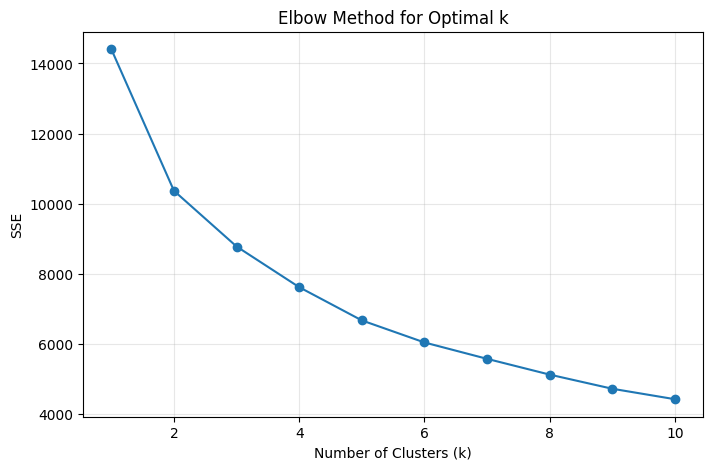

In [6]:
# Calculate SSE for different values of k
sse = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)  # Explicitly set n_init=10
    kmeans.fit(normalized_data)
    sse.append(kmeans.inertia_)

# Draw Elbow Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), sse, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("SSE")
plt.grid(alpha=0.3)
plt.show()

# The optimal number of clusters is at the point where the graph has a significant change (skeletal).


Clustering with K-Means

just doing it for being sure if the data were too sensitive

In [7]:
# K-Means with optimal number of clusters (k=3)
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
categorized_df['Cluster3'] = kmeans.fit_predict(normalized_data)

# Check cluster assignments
print(categorized_df['Cluster3'].value_counts())


Cluster3
1    1066
2    1015
0     800
Name: count, dtype: int64


the good option here, notitably to the diagram, is k=2

In [8]:
# K-Means with optimal number of clusters (k=2)
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
categorized_df['Cluster'] = kmeans.fit_predict(normalized_data)

# Check cluster assignments
print(categorized_df['Cluster'].value_counts())


Cluster
0    1902
1     979
Name: count, dtype: int64


Clustering Visualization

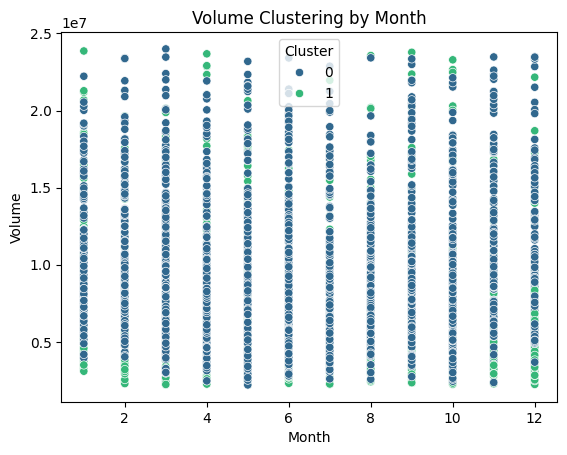

In [9]:
sns.scatterplot(
    x='Month', y='Volume', hue='Cluster', data=categorized_df, palette='viridis'
)
plt.title("Volume Clustering by Month")
plt.xlabel("Month")
plt.ylabel("Volume")
plt.legend(title="Cluster")
plt.show()

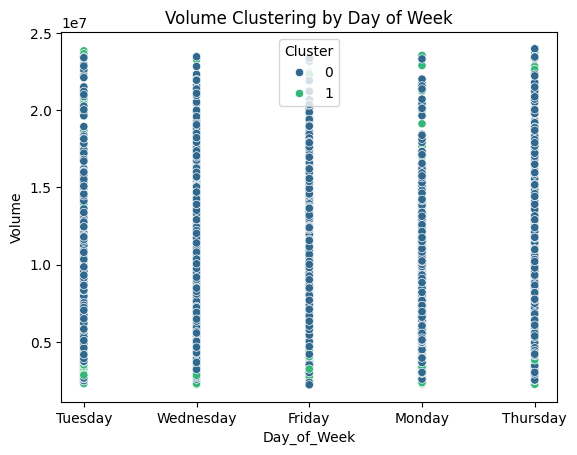

In [10]:
sns.scatterplot(
    x='Day_of_Week', y='Volume', hue='Cluster', data=categorized_df, palette='viridis'
)
plt.title("Volume Clustering by Day of Week")
plt.xlabel("Day_of_Week")
plt.ylabel("Volume")
plt.legend(title="Cluster")
plt.show()

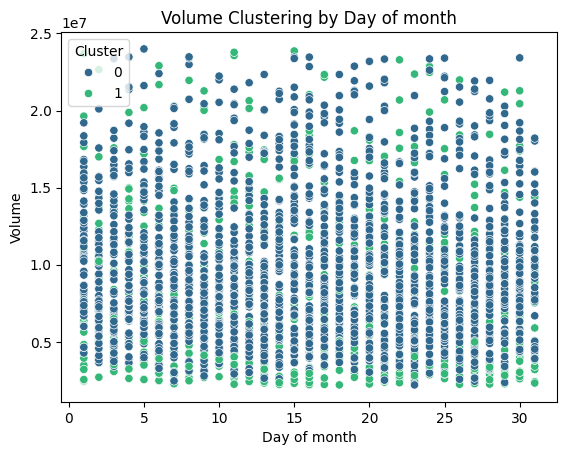

In [11]:
sns.scatterplot(
    x='Day', y='Volume', hue='Cluster', data=categorized_df, palette='viridis'
)
plt.title("Volume Clustering by Day of month")
plt.xlabel("Day of month")
plt.ylabel("Volume")
plt.legend(title="Cluster")
plt.show()

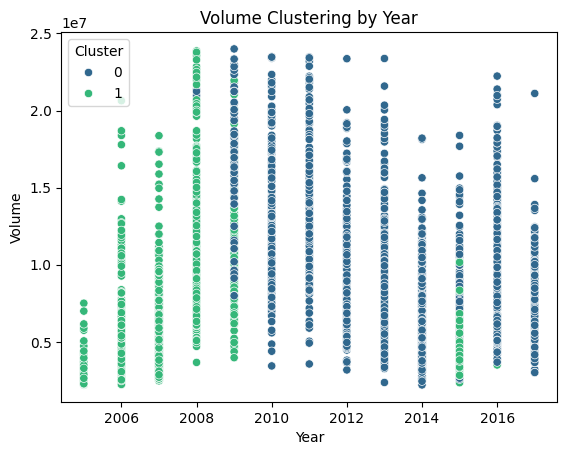

In [12]:
sns.scatterplot(
    x='Year', y='Volume', hue='Cluster', data=categorized_df, palette='viridis'
)
plt.title("Volume Clustering by Year")
plt.xlabel("Year")
plt.ylabel("Volume")
plt.legend(title="Cluster")
plt.show()

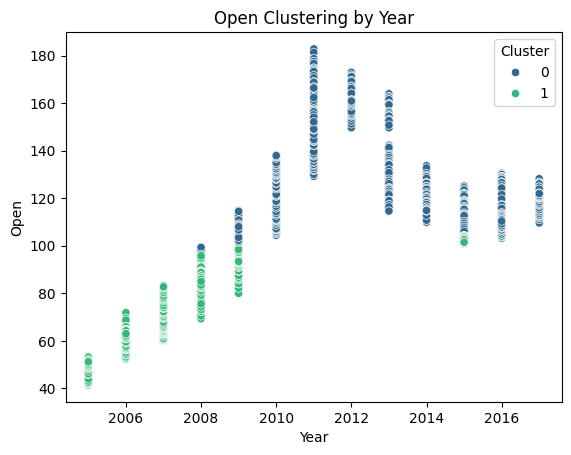

In [13]:
sns.scatterplot(
    x='Year', y='Open', hue='Cluster', data=categorized_df, palette='viridis'
)
plt.title("Open Clustering by Year")
plt.xlabel("Year")
plt.ylabel("Open")
plt.legend(title="Cluster")
plt.show()

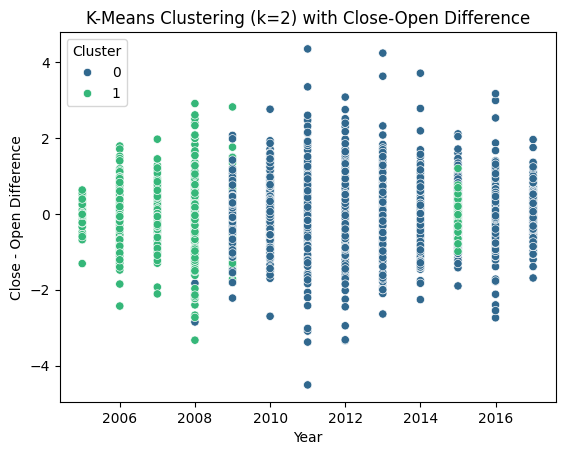

In [14]:
# Create a new column for the difference between Close and Open
categorized_df['Close_Open_Diff'] = categorized_df['Close'] - categorized_df['Open']

# Scatter plot with the difference as y-axis
sns.scatterplot(
    x='Year', y='Close_Open_Diff', hue='Cluster', data=categorized_df, palette='viridis'
)
plt.title("K-Means Clustering (k=2) with Close-Open Difference")
plt.xlabel("Year")
plt.ylabel("Close - Open Difference")
plt.legend(title="Cluster")
plt.show()


تحلیل زمانی خوشه‌ها

Examining seasonal patterns </br>
breaking down clusters by month, day of the week, or year

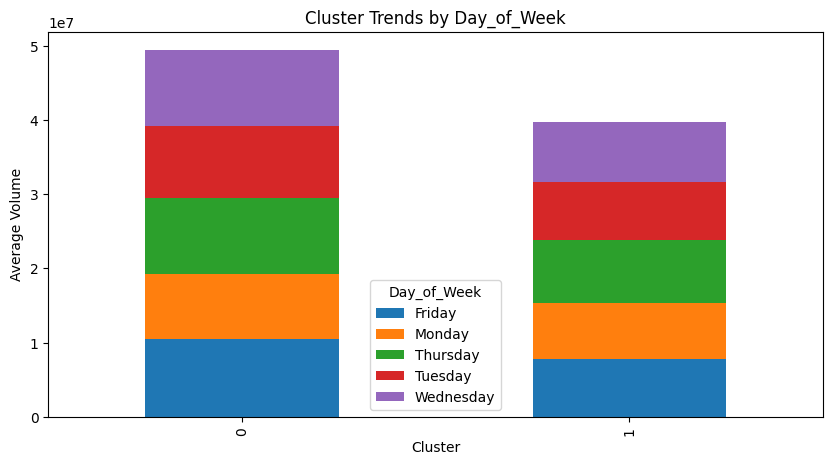

In [15]:
cluster_trends = categorized_df.groupby(['Cluster', 'Day_of_Week'])['Volume'].mean()
# print(cluster_trends)

cluster_trends.unstack().plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title("Cluster Trends by Day_of_Week")
plt.xlabel("Cluster")
plt.ylabel("Average Volume")
plt.show()


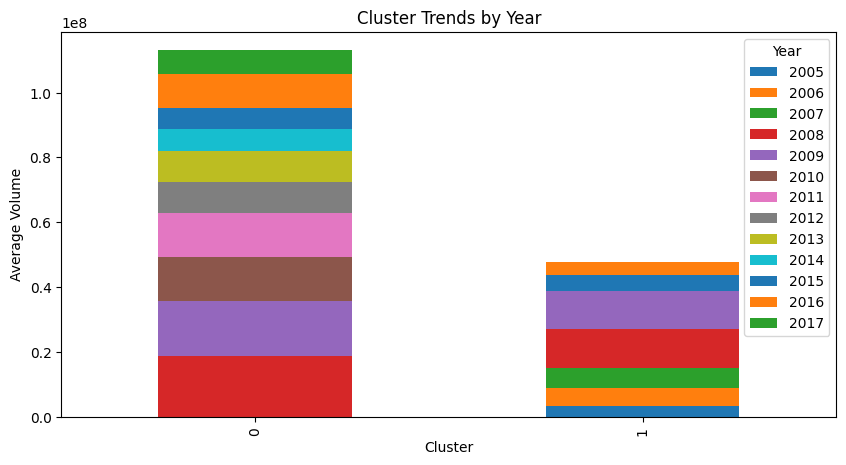

In [16]:
cluster_trends = categorized_df.groupby(['Cluster', 'Year'])['Volume'].mean()
# print(cluster_trends)

cluster_trends.unstack().plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title("Cluster Trends by Year")
plt.xlabel("Cluster")
plt.ylabel("Average Volume")
plt.show()


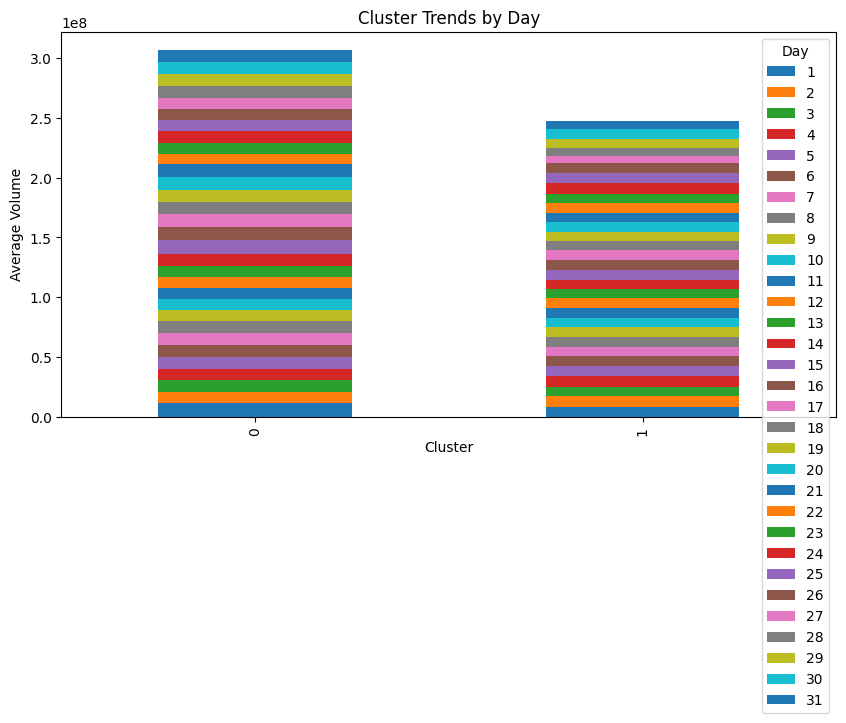

In [17]:
cluster_trends = categorized_df.groupby(['Cluster', 'Day'])['Volume'].mean()
# print(cluster_trends)

cluster_trends.unstack().plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title("Cluster Trends by Day")
plt.xlabel("Cluster")
plt.ylabel("Average Volume")
plt.show()


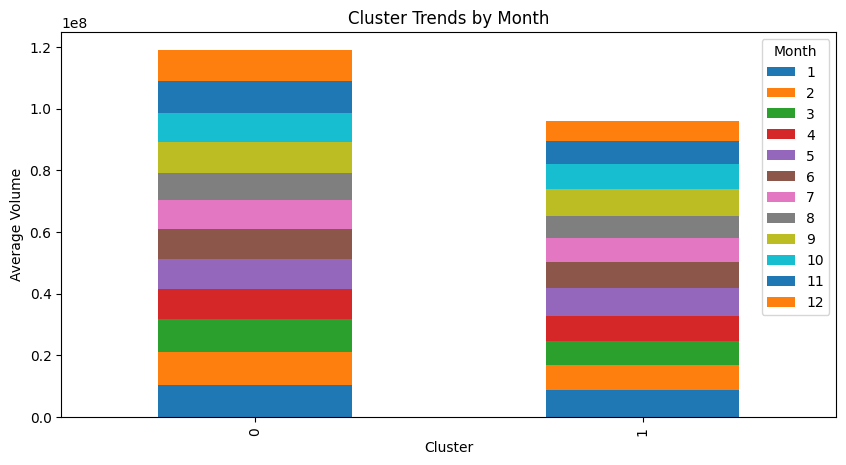

In [18]:
cluster_trends = categorized_df.groupby(['Cluster', 'Month'])['Volume'].mean()
# print(cluster_trends)

cluster_trends.unstack().plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title("Cluster Trends by Month")
plt.xlabel("Cluster")
plt.ylabel("Average Volume")
plt.show()
